In [19]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Load dataset
# -----------------------------
file_path = "carbon-monitor-GLOBAL-maingraphdatas.xlsx"  
df = pd.read_excel(file_path)
print("First 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())
print("\nShape:")
print(df.shape)
print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
  country        date                  sector  MtCO2 per day
0  Brazil  01/01/2023       Domestic Aviation       0.015747
1  Brazil  01/01/2023        Ground Transport       0.274919
2  Brazil  01/01/2023                Industry       0.349250
3  Brazil  01/01/2023  International Aviation       0.015368
4  Brazil  01/01/2023                   Power       0.034601

Columns:
['country', 'date', 'sector', 'MtCO2 per day']

Shape:
(59133, 4)

Missing values:
country          1
date             3
sector           3
MtCO2 per day    3
dtype: int64


In [20]:
# -----------------------------
# 2. Clean column names
# -----------------------------
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\nCleaned columns:")
print(df.columns.tolist())

# -----------------------------
# 3. Convert date column
# -----------------------------
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

print("\nDate conversion check:")
print(df[["date"]].head())
print("\nNull dates:", df["date"].isnull().sum())

# -----------------------------
# 4. Remove rows with invalid dates
# -----------------------------
df = df.dropna(subset=["date"])

print("Rows after removing invalid dates:", len(df))

# -----------------------------
# Step 5 — Check Important Columns
# -----------------------------
print("\nAll columns in dataset:")
print(df.columns)


Cleaned columns:
['country', 'date', 'sector', 'mtco2_per_day']

Date conversion check:
        date
0 2023-01-01
1 2023-01-01
2 2023-01-01
3 2023-01-01
4 2023-01-01

Null dates: 3
Rows after removing invalid dates: 59130

All columns in dataset:
Index(['country', 'date', 'sector', 'mtco2_per_day'], dtype='object')


### Step 6 — Pivot Sectors into Columns

In [21]:
# -----------------------------
# 6. Pivot sectors into columns
# -----------------------------
df_wide = df.pivot_table(
    index=["country", "date"],
    columns="sector",
    values="mtco2_per_day",
    aggfunc="sum"
).reset_index()

# remove sector index name
df_wide.columns.name = None

print("Wide dataframe preview:")
print(df_wide.head())

print("\nShape:")
print(df_wide.shape)

Wide dataframe preview:
  country       date  Domestic Aviation  Ground Transport  Industry  \
0  Brazil 2023-01-01           0.015747          0.274919  0.349250   
1  Brazil 2023-01-02           0.027616          0.332222  0.458161   
2  Brazil 2023-01-03           0.027847          0.495260  0.519262   
3  Brazil 2023-01-04           0.027446          0.542475  0.516304   
4  Brazil 2023-01-05           0.027922          0.562654  0.412759   

   International Aviation     Power  Residential  
0                0.015368  0.034601     0.108845  
1                0.019149  0.045391     0.108845  
2                0.018467  0.051444     0.108845  
3                0.018651  0.051151     0.125003  
4                0.017820  0.040893     0.129563  

Shape:
(9855, 8)


### Step 7 — Clean Sector Column Names and filling missing sector values

In [22]:
df_wide.columns = [str(col).strip().lower().replace(" ", "_") for col in df_wide.columns]

print("Clean columns:")
print(df_wide.columns)

sector_cols = [col for col in df_wide.columns if col not in ["country","date"]]

df_wide[sector_cols] = df_wide[sector_cols].fillna(0)

print("Missing values after filling:")
print(df_wide.isnull().sum())

Clean columns:
Index(['country', 'date', 'domestic_aviation', 'ground_transport', 'industry',
       'international_aviation', 'power', 'residential'],
      dtype='object')
Missing values after filling:
country                   0
date                      0
domestic_aviation         0
ground_transport          0
industry                  0
international_aviation    0
power                     0
residential               0
dtype: int64


### Step 9 — Create Total Emissions Feature

In [23]:
df_wide["total_emissions"] = df_wide[sector_cols].sum(axis=1)

print(df_wide.head())

  country       date  domestic_aviation  ground_transport  industry  \
0  Brazil 2023-01-01           0.015747          0.274919  0.349250   
1  Brazil 2023-01-02           0.027616          0.332222  0.458161   
2  Brazil 2023-01-03           0.027847          0.495260  0.519262   
3  Brazil 2023-01-04           0.027446          0.542475  0.516304   
4  Brazil 2023-01-05           0.027922          0.562654  0.412759   

   international_aviation     power  residential  total_emissions  
0                0.015368  0.034601     0.108845         0.798730  
1                0.019149  0.045391     0.108845         0.991383  
2                0.018467  0.051444     0.108845         1.221125  
3                0.018651  0.051151     0.125003         1.281030  
4                0.017820  0.040893     0.129563         1.191611  


### Step 10 — Save Clean Dataset

In [24]:
df_wide.to_csv("carbon_monitor_cleaned.csv", index=False)

print("Clean dataset saved.")

Clean dataset saved.


### STEP 10.5 — Structural Break Detection (PELT Algorithm)

In [25]:
# -------------------------------------------------------
# STEP 10.5 — Structural Break Detection (PELT Algorithm)
# -------------------------------------------------------
import sys
!{sys.executable} -m pip install ruptures

import ruptures as rpt

country_name = "Brazil"
country_df_br = df_wide[df_wide["country"] == country_name].copy()
country_df_br = country_df_br.sort_values("date").reset_index(drop=True)
ts_df = country_df_br[["date", "total_emissions"]].dropna().reset_index(drop=True)

signal = ts_df["total_emissions"].values.reshape(-1, 1)

algo = rpt.Pelt(model="rbf").fit(signal)
breakpoints = algo.predict(pen=10)
internal_breaks = breakpoints[:-1]

print(f"Number of internal breakpoints detected: {len(internal_breaks)}")
print(f"Breakpoint indexes: {internal_breaks}")

break_dates = []
for bp in internal_breaks:
    bp = min(bp, len(ts_df) - 1)
    break_dates.append(ts_df.loc[bp, "date"])

print("\nDetected break dates:")
for d in break_dates:
    print(" ", d.strftime("%Y-%m-%d"))

boundaries = [0] + internal_breaks + [len(ts_df)]
print("\nEmission statistics per segment:")
for i in range(len(boundaries) - 1):
    segment = ts_df.iloc[boundaries[i]:boundaries[i+1]]
    print(f"  Segment {i+1} "
          f"({segment['date'].iloc[0].strftime('%Y-%m-%d')} -> "
          f"{segment['date'].iloc[-1].strftime('%Y-%m-%d')}): "
          f"mean={segment['total_emissions'].mean():.4f}, "
          f"std={segment['total_emissions'].std():.4f}")

Number of internal breakpoints detected: 3
Breakpoint indexes: [540, 705, 870]

Detected break dates:
  2024-06-25
  2024-12-07
  2025-05-21

Emission statistics per segment:
  Segment 1 (2023-01-01 -> 2024-06-24): mean=1.2945, std=0.1327
  Segment 2 (2024-06-25 -> 2024-12-06): mean=1.4200, std=0.1585
  Segment 3 (2024-12-07 -> 2025-05-20): mean=1.2581, std=0.1278
  Segment 4 (2025-05-21 -> 2025-12-31): mean=1.3976, std=0.1368


In [26]:
means = []

for i in range(len(boundaries) - 1):
    segment = ts_df.iloc[boundaries[i]:boundaries[i+1]]
    mean_val = segment["total_emissions"].mean()
    means.append(mean_val)

# Calculate % change between segments
for i in range(1, len(means)):
    pct_change = (means[i] - means[i-1]) / means[i-1] * 100
    print(f"Change from Segment {i} to {i+1}: {pct_change:.1f}%")

Change from Segment 1 to 2: 9.7%
Change from Segment 2 to 3: -11.4%
Change from Segment 3 to 4: 11.1%


### Step 10.5 — Structural Break with Segment Mean Lines

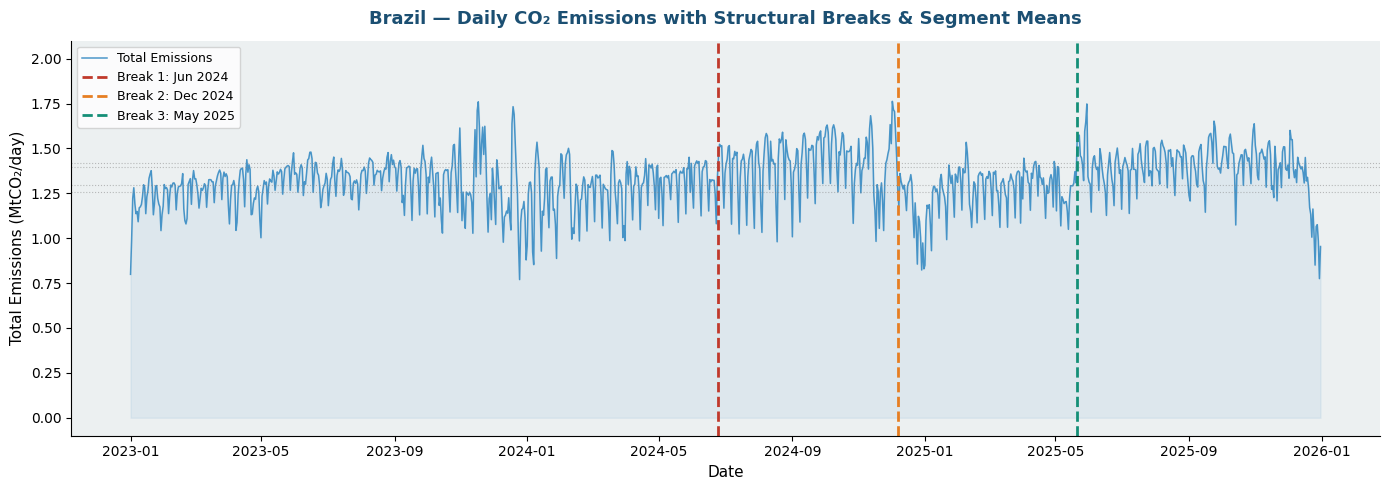

In [27]:
import matplotlib.pyplot as plt
brazil_ts = df_wide[df_wide["country"] == "Brazil"].sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(brazil_ts["date"], brazil_ts["total_emissions"],
        color="#2E86C1", linewidth=1.1, alpha=0.85, label="Total Emissions")
ax.fill_between(brazil_ts["date"], brazil_ts["total_emissions"], alpha=0.08, color="#2E86C1")

import pandas as pd
break_dates  = [pd.Timestamp("2024-06-25"), pd.Timestamp("2024-12-07"), pd.Timestamp("2025-05-21")]
break_colors = ["#C0392B", "#E67E22", "#148F77"]
break_labels = ["Break 1: Jun 2024", "Break 2: Dec 2024", "Break 3: May 2025"]
seg_means    = [1.2945, 1.4200, 1.2581, 1.3976]

boundaries = [brazil_ts["date"].iloc[0]] + break_dates + [brazil_ts["date"].iloc[-1]]
seg_colors_fill = ["#D6EAF8", "#FADBD8", "#D6EAF8", "#FADBD8"]

for i in range(len(boundaries)-1):
    ax.axhspan(0, 2, xmin=0, xmax=1, alpha=0)  # placeholder
    mask = (brazil_ts["date"] >= boundaries[i]) & (brazil_ts["date"] <= boundaries[i+1])
    ax.axhline(seg_means[i], xmin=0, xmax=1, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)

for d, c, lbl in zip(break_dates, break_colors, break_labels):
    ax.axvline(d, color=c, linestyle="--", linewidth=2.0, label=lbl)

ax.set_title("Brazil — Daily CO₂ Emissions with Structural Breaks & Segment Means",
             fontsize=13, fontweight='bold', color="#1B4F72", pad=12)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Total Emissions (MtCO₂/day)", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.set_facecolor("#ECF0F1")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

#### Plot - Segment Mean Comparison (Bar Chart)¶

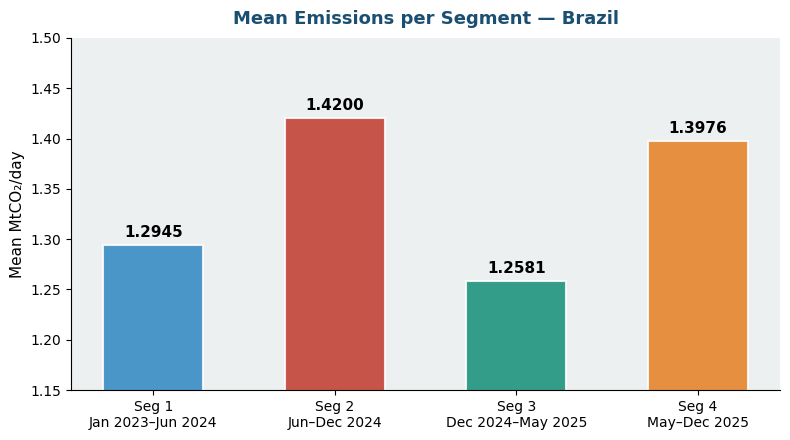

In [28]:
seg_labels = ["Seg 1\nJan 2023–Jun 2024", "Seg 2\nJun–Dec 2024",
               "Seg 3\nDec 2024–May 2025", "Seg 4\nMay–Dec 2025"]
seg_means  = [1.2945, 1.4200, 1.2581, 1.3976]
seg_colors = ["#2E86C1", "#C0392B", "#148F77", "#E67E22"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(seg_labels, seg_means, color=seg_colors, alpha=0.85,
              width=0.55, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, seg_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(1.15, 1.50)
ax.set_title("Mean Emissions per Segment — Brazil", fontsize=13, fontweight='bold', color="#1B4F72", pad=10)
ax.set_ylabel("Mean MtCO₂/day", fontsize=11)
ax.set_facecolor("#ECF0F1")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## Clustering Analysis
### Step 11 — Aggregate Data by Country

In [29]:
# -----------------------------
# 11. Aggregate emissions by country
# -----------------------------
country_features = df_wide.groupby("country").mean(numeric_only=True)

print("Country feature matrix:")
print(country_features.head())

print("\nShape:", country_features.shape)

Country feature matrix:
         domestic_aviation  ground_transport   industry  \
country                                                   
Brazil            0.025729          0.574162   0.523468   
China             0.244164          3.051480  14.783933   
EU27              0.037565          2.084610   1.944696   
India             0.068102          0.996559   2.424825   
Japan             0.028959          0.464472   0.858933   

         international_aviation      power  residential  total_emissions  
country                                                                   
Brazil                 0.019899   0.071462     0.114393         1.329112  
China                  0.097275  13.291269     1.655176        33.123298  
EU27                   0.363286   1.415711     1.068748         6.914617  
India                  0.036469   4.568629     0.753610         8.848195  
Japan                  0.071187   0.945112     0.320706         2.689369  

Shape: (9, 7)


In [30]:
country_features = df_wide.groupby("country").mean()
country_features["total_emissions"]

country
Brazil                 1.329112
China                 33.123298
EU27                   6.914617
India                  8.848195
Japan                  2.689369
ROW                   30.961663
Russian Federation     4.670348
United Kingdom         0.949161
United States         13.627017
Name: total_emissions, dtype: float64

### Plot A — Country Average Emissions (Horizontal Bar)


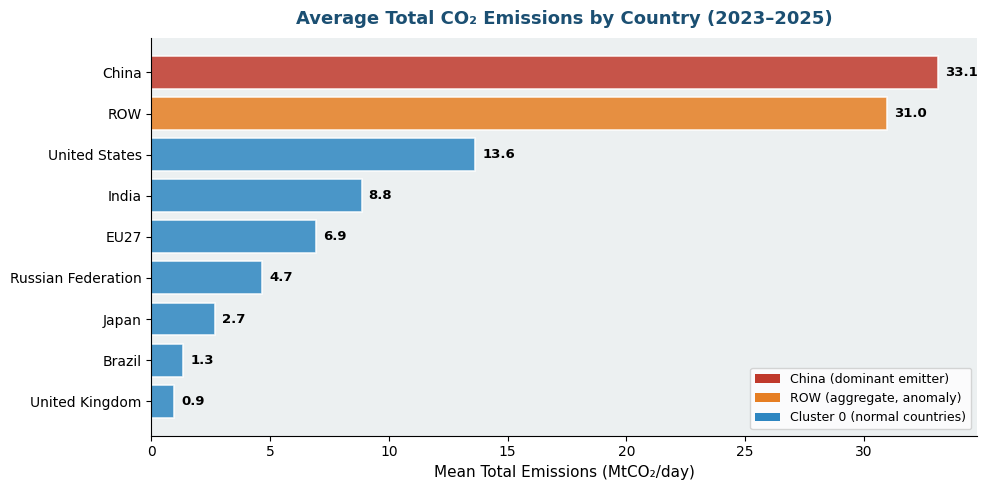

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

country_avg = df_wide.groupby("country")["total_emissions"].mean().sort_values(ascending=False)

NAVY   = "#1B4F72"
BLUE   = "#2E86C1"
ORANGE = "#E67E22"
RED    = "#C0392B"
LGRAY  = "#ECF0F1"

bar_colors = [RED if v > 32 else (ORANGE if v > 15 else BLUE) for v in country_avg.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(country_avg.index[::-1], country_avg.values[::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, country_avg.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va='center', fontsize=9.5, fontweight='bold')

ax.set_title("Average Total CO₂ Emissions by Country (2023–2025)",
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.set_xlabel("Mean Total Emissions (MtCO₂/day)", fontsize=11)
ax.set_facecolor(LGRAY)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('white')

legend_els = [
    mpatches.Patch(facecolor=RED,    label='China (dominant emitter)'),
    mpatches.Patch(facecolor=ORANGE, label='ROW (aggregate, anomaly)'),
    mpatches.Patch(facecolor=BLUE,   label='Cluster 0 (normal countries)')
]
ax.legend(handles=legend_els, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

### Plot B — Sector Breakdown by Country (Stacked Bar)

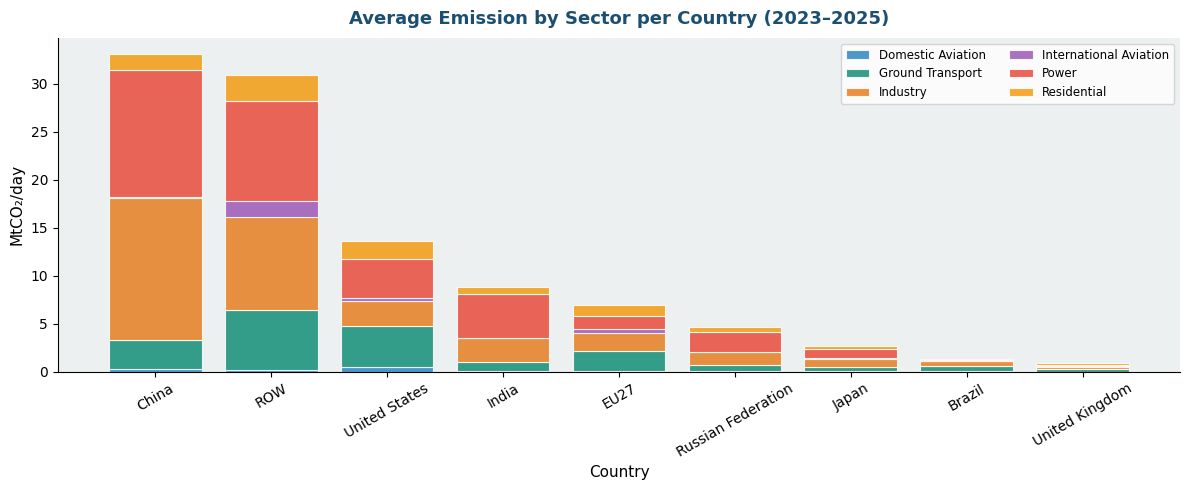

In [32]:
sector_cols_list = ["domestic_aviation", "ground_transport", "industry",
                    "international_aviation", "power", "residential"]

sector_means = df_wide.groupby("country")[sector_cols_list].mean()
sector_means = sector_means.sort_values("industry", ascending=False)

sec_colors = ["#2E86C1", "#148F77", "#E67E22", "#9B59B6", "#E74C3C", "#F39C12"]

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(sector_means))

for col, color in zip(sector_cols_list, sec_colors):
    vals = sector_means[col].values
    ax.bar(sector_means.index, vals, bottom=bottom, color=color, alpha=0.85,
           label=col.replace("_", " ").title(), edgecolor='white', linewidth=0.8)
    bottom += vals

ax.set_title("Average Emission by Sector per Country (2023–2025)",
             fontsize=13, fontweight='bold', color="#1B4F72", pad=10)
ax.set_ylabel("MtCO₂/day", fontsize=11)
ax.set_xlabel("Country", fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8.5, loc="upper right", ncol=2)
ax.set_facecolor("#ECF0F1")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

### Step 12 — Standardize the Data

In [34]:

from sklearn.preprocessing import StandardScaler

# keep only numeric columns
country_features_numeric = country_features.select_dtypes(include=["int64", "float64"])

print(country_features_numeric.dtypes)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_features_numeric)

print("Scaled feature matrix shape:", X_scaled.shape)

domestic_aviation         float64
ground_transport          float64
industry                  float64
international_aviation    float64
power                     float64
residential               float64
total_emissions           float64
dtype: object
Scaled feature matrix shape: (9, 7)


In [35]:
feature_cols = [
    "domestic_aviation",
    "ground_transport",
    "industry",
    "international_aviation",
    "power",
    "residential",
    "total_emissions"
]

scaled_df = pd.DataFrame(
    X_scaled,
    index=country_features.index,
    columns=feature_cols
)

print("Scaled Feature Matrix:")
print(scaled_df.head())

Scaled Feature Matrix:
         domestic_aviation  ground_transport  industry  \
country                                                  
Brazil           -0.669365         -0.760358 -0.700624   
China             0.917095          0.489834  2.330779   
EU27             -0.583397          0.001898 -0.398508   
India            -0.361613         -0.547193 -0.296445   
Japan            -0.645902         -0.815714 -0.629313   

         international_aviation     power  residential  total_emissions  
country                                                                  
Brazil                -0.535249 -0.908651    -1.073276        -0.870620  
China                 -0.382006  2.067829     0.710364         1.862498  
EU27                   0.144824 -0.605989     0.031503        -0.390474  
India                 -0.502432  0.103900    -0.333306        -0.224258  
Japan                 -0.433673 -0.711946    -0.834444        -0.753688  


### Step 13 — Determine Optimal Clusters (Elbow Method)

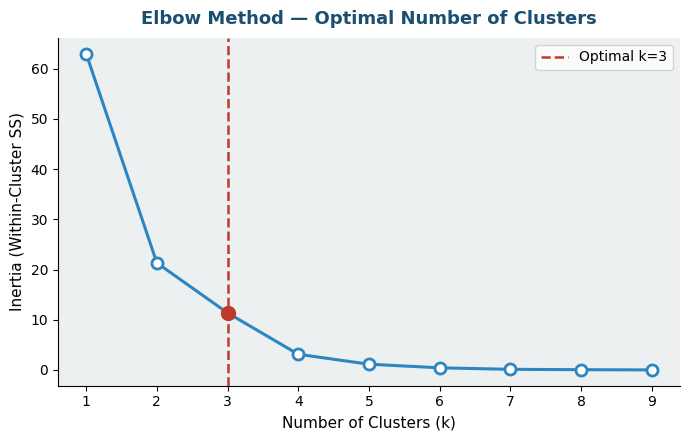

In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

country_features = df_wide.groupby("country").mean(numeric_only=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_features)

inertia = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(k_range), inertia, marker='o', color="#2E86C1", linewidth=2.2,
        markersize=8, markerfacecolor='white', markeredgecolor="#2E86C1", markeredgewidth=2)
ax.axvline(3, color="#C0392B", linestyle='--', linewidth=1.8, label='Optimal k=3')
ax.scatter([3], [inertia[2]], color="#C0392B", zorder=5, s=100)
ax.set_title("Elbow Method — Optimal Number of Clusters",
             fontsize=13, fontweight='bold', color="#1B4F72", pad=10)
ax.set_xlabel("Number of Clusters (k)", fontsize=11)
ax.set_ylabel("Inertia (Within-Cluster SS)", fontsize=11)
ax.legend(fontsize=10)
ax.set_facecolor("#ECF0F1")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

i use Euclidean distance in standardized feature space (StandardScaler applied), consistent with K-Means' assumption."

### Step 14 — Apply K-Means Clustering

In [37]:
# Step 14 — Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42) 
clusters = kmeans.fit_predict(X_scaled)
country_features["cluster"] = clusters

# Full cluster assignment table
print(country_features[["cluster"]].sort_values("cluster"))

                    cluster
country                    
Brazil                    0
EU27                      0
India                     0
Japan                     0
United Kingdom            0
Russian Federation        0
United States             0
ROW                       1
China                     2


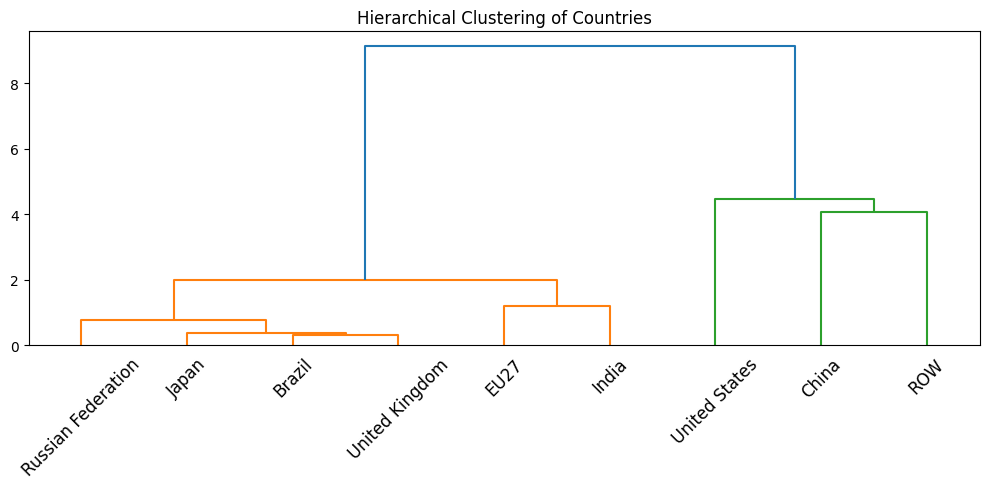

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=country_features.index.tolist(), leaf_rotation=45)
plt.title("Hierarchical Clustering of Countries")
plt.tight_layout()
plt.show()

### Step 15 — Plot — PCA Cluster Scatter (Styled with Labels & Legend)


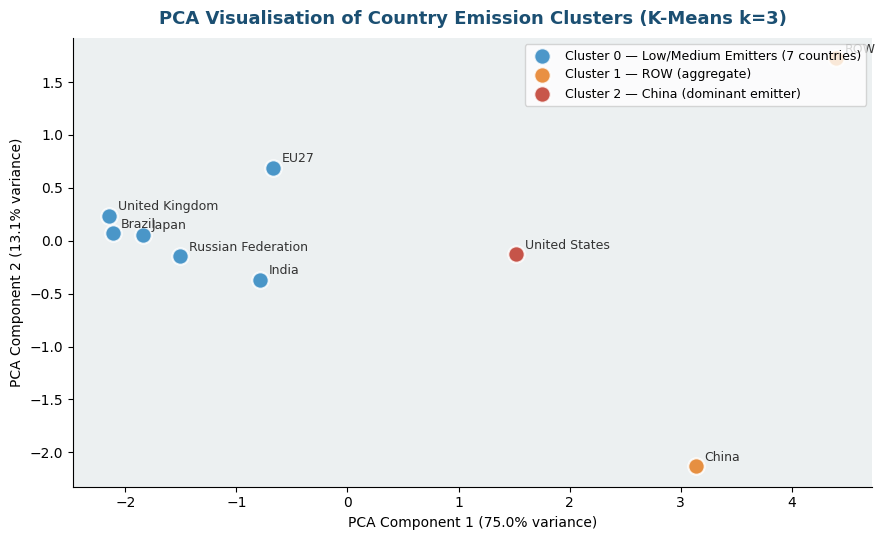

In [39]:
from sklearn.decomposition import PCA

kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters3 = kmeans3.fit_predict(X_scaled)
country_features["cluster"] = clusters3

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
countries_list = country_features.index.tolist()

cluster_colors_map = {0: "#2E86C1", 1: "#E67E22", 2: "#C0392B"}
cluster_label_map  = {0: "Cluster 0 — Low/Medium Emitters (7 countries)",
                      1: "Cluster 1 — ROW (aggregate)",
                      2: "Cluster 2 — China (dominant emitter)"}

fig, ax = plt.subplots(figsize=(9, 5.5))
for cid in [0, 1, 2]:
    mask = clusters3 == cid
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=cluster_colors_map[cid], s=140, alpha=0.85,
               edgecolors='white', linewidth=1.5,
               label=cluster_label_map[cid], zorder=3)

for i, country in enumerate(countries_list):
    ax.annotate(country, (X_pca2[i, 0], X_pca2[i, 1]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=9, color="#333333")

ax.set_title("PCA Visualisation of Country Emission Clusters (K-Means k=3)",
             fontsize=13, fontweight='bold', color="#1B4F72", pad=10)
ax.set_xlabel(f"PCA Component 1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PCA Component 2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=10)
ax.legend(fontsize=9, loc="upper right")
ax.set_facecolor("#ECF0F1")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

### Step 17 — Train the Anomaly Detection Model

In [40]:
from sklearn.ensemble import IsolationForest
# -----------------------------
# 17. Train Isolation Forest
# -----------------------------
iso_forest = IsolationForest(
    contamination=0.05,   # about 5% anomalies
    random_state=42
)

anomaly_labels = iso_forest.fit_predict(X_scaled)

country_features["anomaly"] = anomaly_labels

print(country_features.head())

         domestic_aviation  ground_transport   industry  \
country                                                   
Brazil            0.025729          0.574162   0.523468   
China             0.244164          3.051480  14.783933   
EU27              0.037565          2.084610   1.944696   
India             0.068102          0.996559   2.424825   
Japan             0.028959          0.464472   0.858933   

         international_aviation      power  residential  total_emissions  \
country                                                                    
Brazil                 0.019899   0.071462     0.114393         1.329112   
China                  0.097275  13.291269     1.655176        33.123298   
EU27                   0.363286   1.415711     1.068748         6.914617   
India                  0.036469   4.568629     0.753610         8.848195   
Japan                  0.071187   0.945112     0.320706         2.689369   

         cluster  anomaly  
country                  

### Step 18 — Show Only Anomalies

In [41]:
# -----------------------------
# 18. Show anomaly countries
# -----------------------------
anomalies = country_features[country_features["anomaly"] == -1]

print("Anomalous countries:")
print(anomalies)

Anomalous countries:
         domestic_aviation  ground_transport  industry  \
country                                                  
ROW               0.155452          6.310938  9.609712   

         international_aviation      power  residential  total_emissions  \
country                                                                    
ROW                    1.687054  10.389342     2.809165        30.961663   

         cluster  anomaly  
country                    
ROW            1       -1  


### Step 19 — Plot — Anomaly Detection 


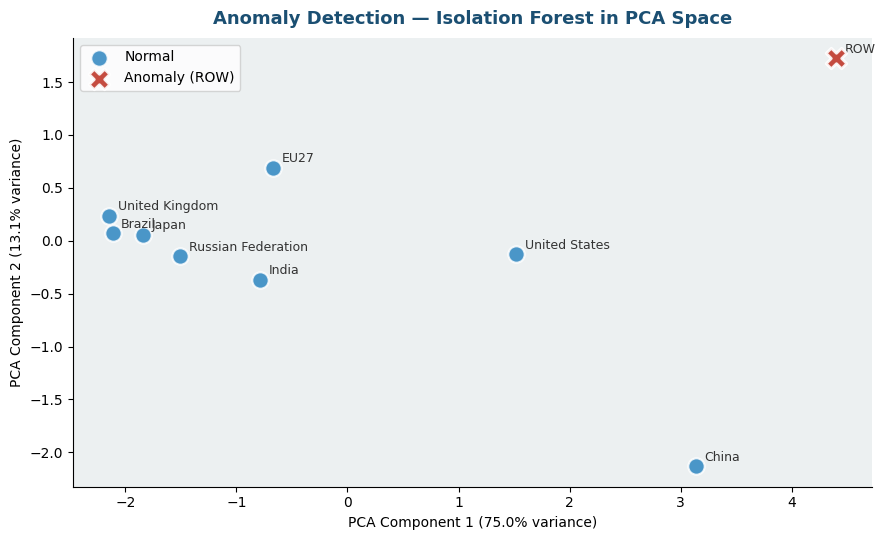

In [42]:
from sklearn.ensemble import IsolationForest

iso2 = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels2 = iso2.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(9, 5.5))
normal_mask  = anomaly_labels2 == 1
anomaly_mask = anomaly_labels2 == -1

ax.scatter(X_pca2[normal_mask, 0], X_pca2[normal_mask, 1],
           c="#2E86C1", s=140, alpha=0.85, edgecolors='white',
           linewidth=1.5, label="Normal", zorder=3)
ax.scatter(X_pca2[anomaly_mask, 0], X_pca2[anomaly_mask, 1],
           c="#C0392B", s=220, alpha=0.9, edgecolors='white',
           linewidth=2, marker='X', label="Anomaly (ROW)", zorder=4)

for i, country in enumerate(countries_list):
    ax.annotate(country, (X_pca2[i, 0], X_pca2[i, 1]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=9, color="#333333")

ax.set_title("Anomaly Detection — Isolation Forest in PCA Space",
             fontsize=13, fontweight='bold', color="#1B4F72", pad=10)
ax.set_xlabel(f"PCA Component 1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PCA Component 2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=10)
ax.legend(fontsize=10)
ax.set_facecolor("#ECF0F1")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

### LSTM forecasting

In [43]:
# --- Univariate LSTM Baseline ---
import sys
!{sys.executable} -m pip install tensorflow
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt


  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp310-cp310-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.80.0-cp310-cp310-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.12.2-py3-none-any.whl.metadata (5.9 kB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl.metadata (2.7 kB)
  Using cached m

### Step 20 — Select One Country

In [44]:
# -----------------------------
# 20. Select one country
# -----------------------------
country_name = "Brazil"

country_df = df_wide[df_wide["country"] == country_name].copy()
country_df = country_df.sort_values("date")

print(country_df[["date", "total_emissions"]].head())
print("\nShape:", country_df.shape)

        date  total_emissions
0 2023-01-01         0.798730
1 2023-01-02         0.991383
2 2023-01-03         1.221125
3 2023-01-04         1.281030
4 2023-01-05         1.191611

Shape: (1095, 9)


### Step 21 — Plot the Time Series

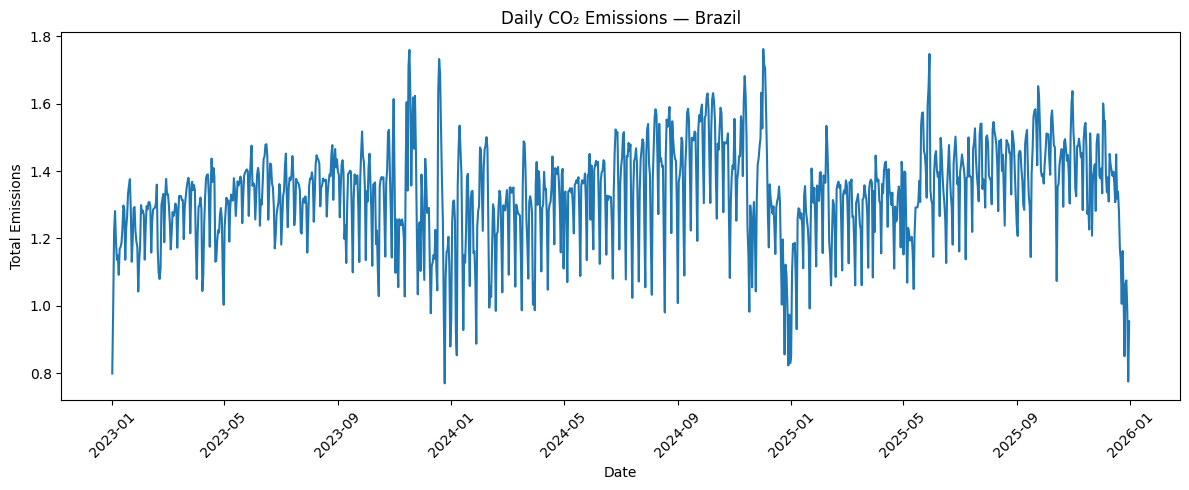

In [45]:
# -----------------------------
# 21. Visualize emissions over time
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(country_df["date"], country_df["total_emissions"])
plt.xlabel("Date")
plt.ylabel("Total Emissions")
plt.title(f"Daily CO₂ Emissions — {country_name}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 22 — Build the LSTM Model

In [46]:
# Scale
scaler_ts = MinMaxScaler()
emissions_scaled = scaler_ts.fit_transform(country_df[["total_emissions"]])

# Create sequences
seq_length = 30
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(emissions_scaled, seq_length)

# Train/test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build model
model = Sequential([
    Input(shape=(seq_length, 1)),
    LSTM(50, activation="tanh"),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.summary()

# Train
model.fit(X_train, y_train, epochs=30, batch_size=16,
          validation_split=0.1, verbose=0)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### Step 23 — Evaluate the Model

In [47]:
y_pred = model.predict(X_test)
y_test_inv = scaler_ts.inverse_transform(y_test)
y_pred_inv = scaler_ts.inverse_transform(y_pred)

mae  = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"Univariate LSTM - MAE: {mae:.4f} | RMSE: {rmse:.4f}")
print("→ Baseline established. Now upgrading to multivariate LSTM.")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Univariate LSTM - MAE: 0.0776 | RMSE: 0.1029
→ Baseline established. Now upgrading to multivariate LSTM.


The univariate LSTM uses only total_emissions as input.
Since the dataset is multivariate, we now build a stronger model using all 6 sector columns.

### Step 24 — Select Input Features

In [48]:
# -----------------------------
# 24. Select multivariate features
# -----------------------------
feature_cols = [
    "domestic_aviation",
    "ground_transport",
    "industry",
    "international_aviation",
    "power",
    "residential"
]

target_col = "total_emissions"

country_name = "Brazil"

country_df = df_wide[df_wide["country"] == country_name].copy()
country_df = country_df.sort_values("date")

print(country_df[feature_cols + [target_col]].head())

   domestic_aviation  ground_transport  industry  international_aviation  \
0           0.015747          0.274919  0.349250                0.015368   
1           0.027616          0.332222  0.458161                0.019149   
2           0.027847          0.495260  0.519262                0.018467   
3           0.027446          0.542475  0.516304                0.018651   
4           0.027922          0.562654  0.412759                0.017820   

      power  residential  total_emissions  
0  0.034601     0.108845         0.798730  
1  0.045391     0.108845         0.991383  
2  0.051444     0.108845         1.221125  
3  0.051151     0.125003         1.281030  
4  0.040893     0.129563         1.191611  


### Step 25 — Scale Inputs and Target Separately

In [49]:
# -----------------------------
# 25. Scale features and target
# -----------------------------
from sklearn.preprocessing import MinMaxScaler
import numpy as np

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_features_scaled = feature_scaler.fit_transform(country_df[feature_cols])
y_target_scaled = target_scaler.fit_transform(country_df[[target_col]])

print("Feature shape:", X_features_scaled.shape)
print("Target shape :", y_target_scaled.shape)

Feature shape: (1095, 6)
Target shape : (1095, 1)


### Step 26 — Create Multivariate Sequences

In [50]:
# -----------------------------
# 26. Create multivariate sequences
# -----------------------------
def create_multivariate_sequences(X_data, y_data, seq_length=30):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - seq_length):
        X_seq.append(X_data[i:i + seq_length])
        y_seq.append(y_data[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 30

X_multi, y_multi = create_multivariate_sequences(
    X_features_scaled,
    y_target_scaled,
    seq_length
)

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (1065, 30, 6)
y_multi shape: (1065, 1)


### Step 27 — Train/Test Split

In [51]:
# -----------------------------
# 27. Train/test split
# -----------------------------
train_size = int(len(X_multi) * 0.8)

X_train_m, X_test_m = X_multi[:train_size], X_multi[train_size:]
y_train_m, y_test_m = y_multi[:train_size], y_multi[train_size:]

print("Train:", X_train_m.shape, y_train_m.shape)
print("Test :", X_test_m.shape, y_test_m.shape)

Train: (852, 30, 6) (852, 1)
Test : (213, 30, 6) (213, 1)


### Step 28 — Build Multivariate LSTM Model

In [52]:
# -----------------------------
# 28. Build multivariate LSTM
# -----------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model_multi = Sequential([
    Input(shape=(seq_length, len(feature_cols))),
    LSTM(64, activation="tanh"),
    Dense(1)
])

model_multi.compile(optimizer="adam", loss="mse")

model_multi.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

### Step 29 — Train the Multivariate LSTM

In [53]:
# -----------------------------
# 29. Train multivariate model
# -----------------------------
history_multi = model_multi.fit(
    X_train_m,
    y_train_m,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0410 - val_loss: 0.0173
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0215 - val_loss: 0.0152
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0199 - val_loss: 0.0149
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0190 - val_loss: 0.0136
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0183 - val_loss: 0.0143
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0183 - val_loss: 0.0135
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0167 - val_loss: 0.0107
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0155 - val_loss: 0.0108
Epoch 9/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0145 - val_loss: 0.0098
Epoch 10/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0142 - val_loss: 0.0094
Epoch 11/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0134 - val_loss: 0.0095
Epoch 12/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0

### Step 30 — Plot Training History

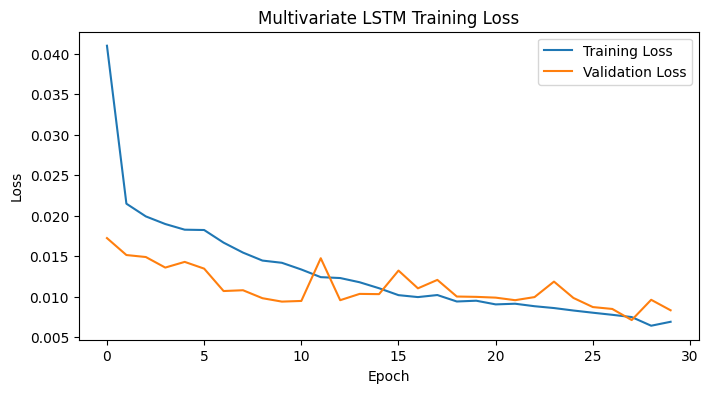

In [54]:
# -----------------------------
# 30. Plot training history
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history_multi.history["loss"], label="Training Loss")
plt.plot(history_multi.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multivariate LSTM Training Loss")
plt.legend()
plt.show()

### Step 31 — Predict on Test Set

In [55]:
# -----------------------------
# 31. Predict
# -----------------------------
y_pred_m = model_multi.predict(X_test_m)

# inverse transform target
y_test_m_inv = target_scaler.inverse_transform(y_test_m)
y_pred_m_inv = target_scaler.inverse_transform(y_pred_m)

print("First 5 predictions:")
for i in range(5):
    print(f"Real: {y_test_m_inv[i][0]:.4f} | Pred: {y_pred_m_inv[i][0]:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
First 5 predictions:
Real: 1.3013 | Pred: 1.1885
Real: 1.1451 | Pred: 1.1919
Real: 1.3947 | Pred: 1.3264
Real: 1.4463 | Pred: 1.3451
Real: 1.4592 | Pred: 1.3925


### Step 32— Evaluate the Model

In [56]:
# -----------------------------
# 32. Evaluation
# -----------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_m = mean_absolute_error(y_test_m_inv, y_pred_m_inv)
mse_m = mean_squared_error(y_test_m_inv, y_pred_m_inv)
rmse_m = np.sqrt(mse_m)

print("Multivariate LSTM Results")
print("MAE :", mae_m)
print("MSE :", mse_m)
print("RMSE:", rmse_m)

Multivariate LSTM Results
MAE : 0.06676719803184546
MSE : 0.00800785639447183
RMSE: 0.08948662690297265


#### Plot H — LSTM Model Comparison (MAE & RMSE)

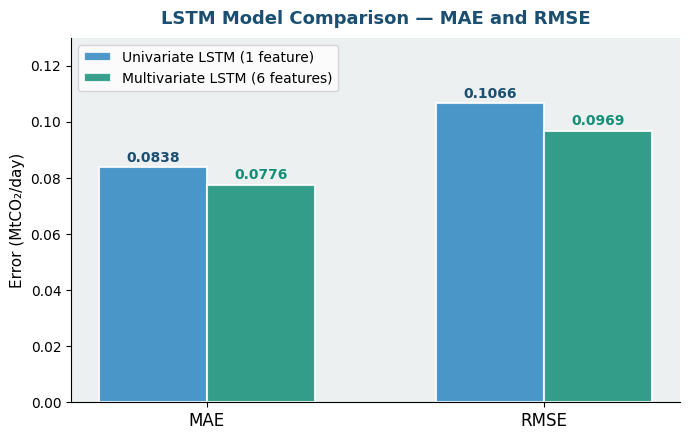

In [57]:
metrics  = ['MAE', 'RMSE']
uni_vals   = [0.0838, 0.1066]   
multi_vals = [0.0776, 0.0969]
x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar(x - width/2, uni_vals, width, label='Univariate LSTM (1 feature)',
            color="#2E86C1", alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax.bar(x + width/2, multi_vals, width, label='Multivariate LSTM (6 features)',
            color="#148F77", alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, val in zip(b1, uni_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold', color="#1B4F72")
for bar, val in zip(b2, multi_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold', color="#148F77")

ax.set_title("LSTM Model Comparison — MAE and RMSE",
             fontsize=13, fontweight='bold', color="#1B4F72", pad=10)
ax.set_ylabel("Error (MtCO₂/day)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.13)
ax.set_facecolor("#ECF0F1")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

### Step 33 — Plot Real vs Predicted

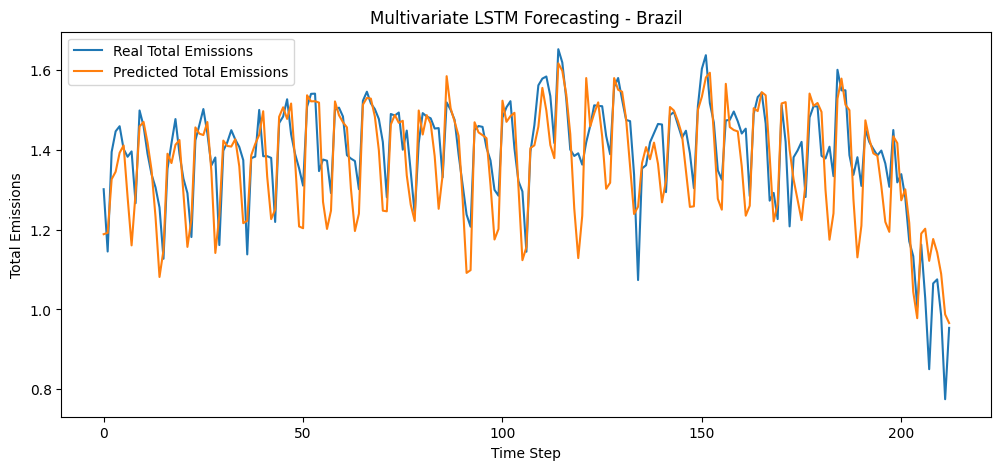

In [58]:
# -----------------------------
# 33. Plot predictions
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(y_test_m_inv, label="Real Total Emissions")
plt.plot(y_pred_m_inv, label="Predicted Total Emissions")
plt.xlabel("Time Step")
plt.ylabel("Total Emissions")
plt.title(f"Multivariate LSTM Forecasting - {country_name}")
plt.legend()
plt.show()